In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dem_to_matrix import (
    load_csv_data,
    transform_coordinates_to_target_crs,
    resample_dem_to_target_resolution,
    normalize_elevation_data,
    apply_global_stream_threshold,
    create_polygon_mask,
    crop_to_bounds,
    transform_food_cache_coordinates,
    save_dem_outputs
)
from pyproj import Transformer
from matplotlib.path import Path as MplPath

sys.path.append('../..')
from beaversim.ral.backend.modules.module_colors import ColorMaps
colors = ColorMaps()

print("Modules loaded successfully")

Modules loaded successfully


In [2]:
REGION = 'isleroyal'

REGION_CONFIGS = {
    'isleroyal': {
        'name': 'IsleRoyal',
        'csv_path': './example_datasets/ISLE_ROYAL/IsleRoyal.csv',
        'epsg_geographic': 'EPSG:4326',
        'epsg_source': 'EPSG:3590',
        'epsg_target': 'EPSG:3590',
        'polygon_corners': [
            (-88.904798, 47.960272),  # NW
            (-88.916436, 47.955043),  # SW
            (-88.914804, 47.953055),  # SE
            (-88.901325, 47.958142)   # NE
        ],
        'food_cache_latlon': (47.956878, -88.910891),  # Center of region
        'target_resolution_m': 6.0,
        'output_dir': './output/IsleRoyal'
    }
}

config = REGION_CONFIGS[REGION]

print(f"Configuration loaded: {config['name']}")
print(f"CSV: {config['csv_path']}")
print(f"Source CRS: {config['epsg_source']}")
print(f"Target CRS: {config['epsg_target']}")
print(f"Output directory: {config['output_dir']}")

Configuration loaded: IsleRoyal
CSV: ./example_datasets/ISLE_ROYAL/IsleRoyal.csv
Source CRS: EPSG:3590
Target CRS: EPSG:3590
Output directory: ./output/IsleRoyal


In [3]:
epsg_geographic = config['epsg_geographic']
epsg_source = config['epsg_source']
epsg_target = config['epsg_target']

print(f"EPSG Geographic CRS: {epsg_geographic}")
print(f"EPSG Source CRS: {epsg_source}")
print(f"EPSG Target CRS: {epsg_target}")

EPSG Geographic CRS: EPSG:4326
EPSG Source CRS: EPSG:3590
EPSG Target CRS: EPSG:3590


In [4]:
csv_path = config['csv_path']

df, coordinates_are_projected = load_csv_data(csv_path)

print(f"Data loaded: {len(df)} elevation points")
print(f"Coordinate type: {'Projected' if coordinates_are_projected else 'Geographic'}")

Detected projected coordinates (x, y values > geographic range)

Data loaded: 237824 points
X/Lon range: [25776999.000000, 25780719.000000]
Y/Lat range: [1161959.000000, 1164251.000000]
Elevation range: [624.83, 902.50] m
Data loaded: 237824 elevation points
Coordinate type: Projected


In [5]:
target_resolution_m = config['target_resolution_m']
interpolation_method = 'linear'

print(f"Target resolution: {target_resolution_m}m per pixel")
print(f"Interpolation method: {interpolation_method}")

Target resolution: 6.0m per pixel
Interpolation method: linear


In [6]:
X, Y, Z = resample_dem_to_target_resolution(df, target_resolution_m, interpolation_method)

print(f"Resampled data shape: {Z.shape}")
print(f"Grid dimensions: {Z.shape[0]} x {Z.shape[1]} pixels")
print(f"Approximate area: {(X.max()-X.min())*(Y.max()-Y.min()):.2f} m²")

Checking resolution...
Original data bounds: x[25776999.00, 25780719.00], y[1161959.00, 1164251.00]
Original resolution: 6.00m x 6.00m
  Target resolution (6.0m) matches original resolution - skipping resampling
Resampled data shape: (383, 621)
Grid dimensions: 383 x 621 pixels
Approximate area: 8526240.00 m²


In [7]:
Z_norm = normalize_elevation_data(Z)

print(f"Normalized elevation data")
print(f"Land values now in range [0, 1]")

Normalizing elevation data:
  Original elevation range: [624.83, 902.50] m
  Valid land pixels: 237,824 (100.0%)
  Water/invalid pixels: 19 (0.0%)
  Normalized range: [0.00, 1.00]
Normalized elevation data
Land values now in range [0, 1]


In [8]:
threshold_percentile = 0

Z = apply_global_stream_threshold(Z_norm, threshold_percentile)

print(f"Stream threshold applied globally")


Stream removal: skipped (threshold_percentile = 0)
Stream threshold applied globally


In [9]:
if epsg_source != epsg_target:
    df, X, Y = transform_coordinates_to_target_crs(df, X, Y, epsg_source, epsg_target)
    print(f"Coordinates transformed from {epsg_source} to {epsg_target}")
else:
    print(f"Source and target CRS are the same - no transformation needed")

Source and target CRS are the same - no transformation needed


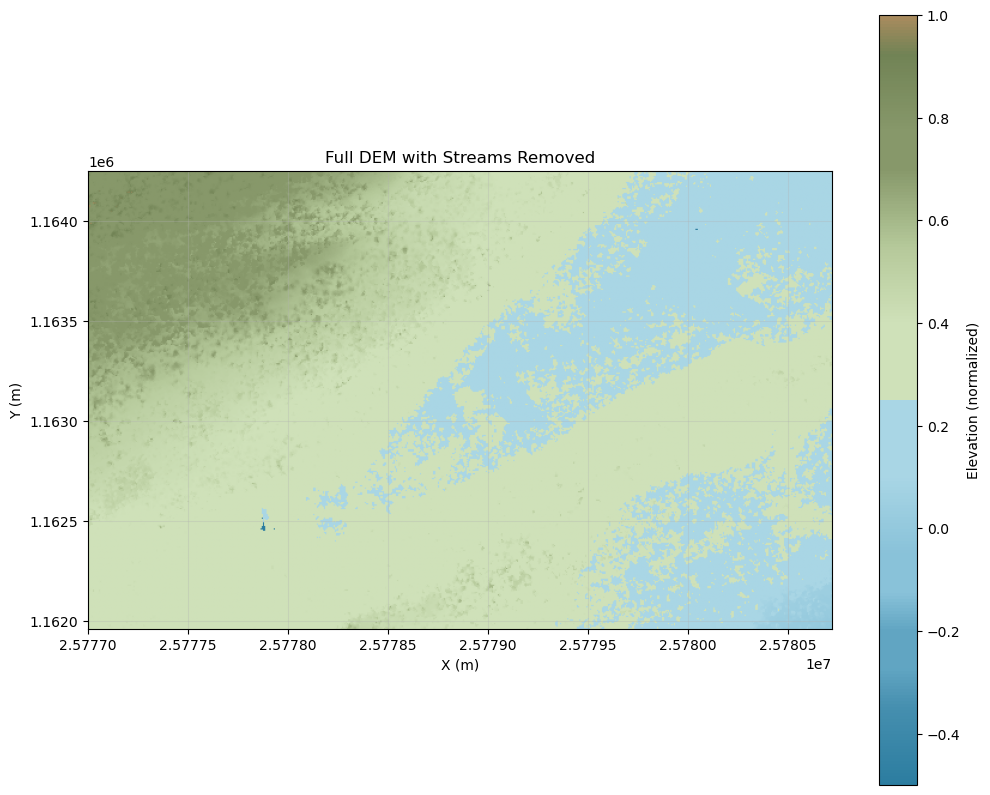

In [10]:
plt.figure(figsize=(12, 10))
plt.imshow(Z, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap=colors._bluebrowngreen_colormap)
plt.colorbar(label='Elevation (normalized)')
plt.title('Full DEM with Streams Removed')
plt.xlabel('X (m)' if coordinates_are_projected else 'Longitude')
plt.ylabel('Y (m)' if coordinates_are_projected else 'Latitude')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
polygon_corners = config['polygon_corners']

print(f"Region: {config['name']}")
if len(polygon_corners) > 0:
    print(f"Polygon defined with {len(polygon_corners)} corners")
else:
    print("Using entire map (no polygon restriction)")

Region: IsleRoyal
Polygon defined with 4 corners


Using polygon with 4 corners
Polygon bounds: x[25776993.74, 25780723.91], y[1161681.00, 1164254.75]
Points inside region: 94433 / 237843
Points inside region: 94433 / 237843
Polygon bounds: x[25776993.74, 25780723.91], y[1161681.00, 1164254.75]
DEM extent: x[25776999.00, 25780719.00], y[1161959.00, 1164251.00]


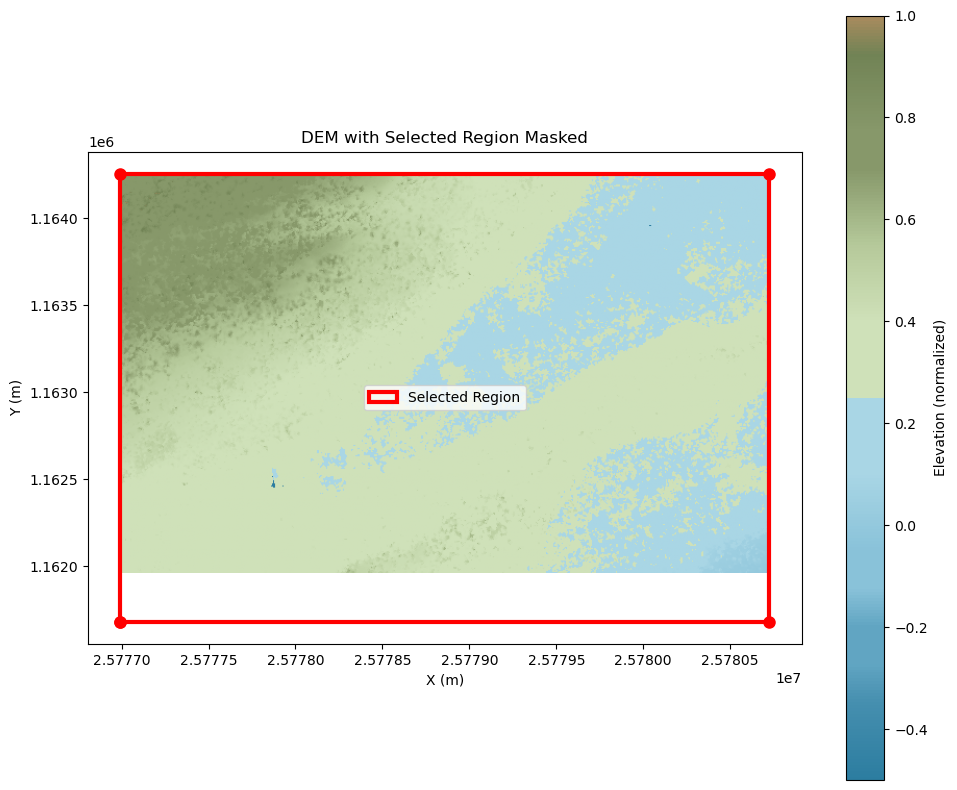

In [16]:
inside_grid, (xmin, xmax, ymin, ymax), df = create_polygon_mask(
    X, Y, polygon_corners, coordinates_are_projected, 
    epsg_geographic, epsg_target, df
)

print(f"Points inside region: {np.sum(inside_grid)} / {inside_grid.size}")
print(f"Polygon bounds: x[{xmin:.2f}, {xmax:.2f}], y[{ymin:.2f}, {ymax:.2f}]")
print(f"DEM extent: x[{X.min():.2f}, {X.max():.2f}], y[{Y.min():.2f}, {Y.max():.2f}]")

plt.figure(figsize=(10, 8))
plt.imshow(Z, extent=[X.min(), X.max(), Y.min(), Y.max()], origin='lower', cmap=colors._bluebrowngreen_colormap)
plt.title('DEM with Selected Region Masked')
plt.colorbar(label='Elevation (normalized)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')

if len(polygon_corners) > 0:
    from matplotlib.patches import Rectangle
    rect = Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                     linewidth=3, edgecolor='red', facecolor='none', label='Selected Region')
    plt.gca().add_patch(rect)
    plt.legend()
    
    # Add corner markers for debugging
    plt.plot([xmin, xmax, xmax, xmin, xmin], 
             [ymin, ymin, ymax, ymax, ymin], 
             'ro-', markersize=8, linewidth=2, label='Polygon Corners')

plt.tight_layout()
plt.show()

In [13]:
food_cache_latlon = config['food_cache_latlon']

tf = Transformer.from_crs(epsg_geographic, epsg_target, always_xy=True)
food_cache_x, food_cache_y = tf.transform(food_cache_latlon[1], food_cache_latlon[0])

print(f"Food cache coordinates:")
print(f"  Geographic: {food_cache_latlon}")
print(f"  Projected: ({food_cache_x:.2f}, {food_cache_y:.2f})")

Food cache coordinates:
  Geographic: (47.956878, -88.910891)
  Projected: (25778368.71, 1163052.52)


In [14]:
Z_cropped, X_clipped, Y_clipped, x_clipped, y_clipped = crop_to_bounds(
    Z, X, Y, (xmin, xmax, ymin, ymax)
)

print(f"Cropped to region bounds")
print(f"Shape: {Z_cropped.shape}")
print(f"X range: [{x_clipped.min():.2f}, {x_clipped.max():.2f}]")
print(f"Y range: [{y_clipped.min():.2f}, {y_clipped.max():.2f}]")

output_dir = config['output_dir']

food_cache_proj, food_cache_idx, food_cache_in_bounds = transform_food_cache_coordinates(
    food_cache_latlon, x_clipped, y_clipped,
    epsg_geographic, epsg_target
)

save_dem_outputs(
    output_dir, Z_cropped, X_clipped, Y_clipped,
    x_clipped, y_clipped, target_resolution_m, interpolation_method,
    food_cache_latlon, food_cache_proj, food_cache_idx, food_cache_in_bounds,
    epsg_target
)

print(f"\nProcessing complete!")
print(f"Matrix shape: {Z_cropped.shape}")
print(f"Resolution: {target_resolution_m}m per pixel")
print(f"Output directory: {output_dir}")

Cropped to region bounds
Shape: (383, 621)
X range: [25776999.00, 25780719.00]
Y range: [1161959.00, 1164251.00]
Food cache coordinates: (25778368.71, 1163052.52)
Food cache matrix indices: (228, 182)
Food cache within bounds: True

  Saved to ./output/IsleRoyal:
  - elevation.npy: (383, 621)
  - X_coordinates.npy: (383, 621)
  - Y_coordinates.npy: (383, 621)
  - processing_metadata.json

Processing complete!
Matrix shape: (383, 621)
Resolution: 6.0m per pixel
Output directory: ./output/IsleRoyal


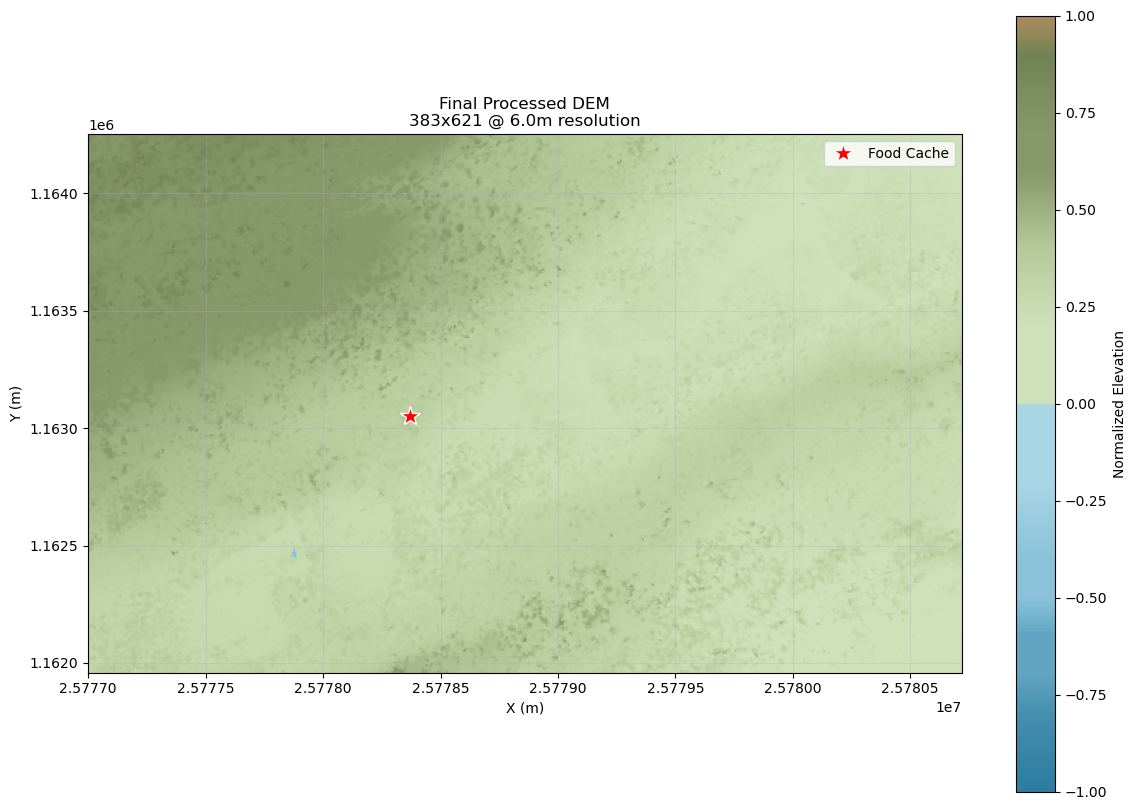


Conversion complete!


In [15]:
plt.figure(figsize=(12, 10))

extent = [
    x_clipped.min(),
    x_clipped.max(),
    y_clipped.min(),
    y_clipped.max()
]

plt.imshow(Z_cropped, extent=extent,
           origin='lower', cmap=colors._bluebrowngreen_colormap, aspect='equal',
           vmin=-1, vmax=1)
plt.colorbar(label='Normalized Elevation', shrink=0.8)

if food_cache_in_bounds:
    plt.plot(food_cache_proj[0], food_cache_proj[1], 'r*', markersize=15, 
             label='Food Cache', markeredgecolor='white', markeredgewidth=1)
    plt.legend()

plt.title(f'Final Processed DEM\n{Z_cropped.shape[0]}x{Z_cropped.shape[1]} @ {target_resolution_m}m resolution')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nConversion complete!")